# Prévision de la consommation du lendemain

Objectif : peut-on prévoir la consommation moyenne de demain ?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
eco2mix=pd.read_csv("../data/eco2mix_2023_2024.csv", sep=";")
eco2mix=eco2mix.dropna(subset=['consommation'])
eco2mix['date_heure']=pd.to_datetime(eco2mix['date_heure'])
meteo=pd.read_csv('../data/meteo_2023_2024.csv', sep=',')
meteo['date_heure'] = pd.to_datetime(meteo['date_heure']).dt.tz_localize("UTC")
eco2mix["date"] = eco2mix["date_heure"].dt.floor("D")
meteo["date"] = meteo["date_heure"].dt.floor("D")
conso_jour = eco2mix.groupby('date')['consommation'].mean().reset_index()
temp_jour = meteo.groupby('date')['temp_france'].mean().reset_index()
df_jour=pd.merge(conso_jour,temp_jour,on='date')

In [3]:
df_jour.count()

date            731
consommation    731
temp_france     731
dtype: int64

In [4]:
df_jour.head()

,date,consommation,temp_france
0,2023-01-01 00:00:00+00:00,43010.500000,13.369792
1,2023-01-02 00:00:00+00:00,50014.312500,11.054688
2,2023-01-03 00:00:00+00:00,56098.625000,8.559375
3,2023-01-04 00:00:00+00:00,56889.291667,9.498958
4,2023-01-05 00:00:00+00:00,55379.729167,10.456250


In [5]:
df_jour["conso_veille"] = df_jour["consommation"].shift(1)

In [6]:
df_jour.head()

,date,consommation,temp_france,conso_veille
0,2023-01-01 00:00:00+00:00,43010.500000,13.369792,NaN
1,2023-01-02 00:00:00+00:00,50014.312500,11.054688,43010.500000
2,2023-01-03 00:00:00+00:00,56098.625000,8.559375,50014.312500
3,2023-01-04 00:00:00+00:00,56889.291667,9.498958,56098.625000
4,2023-01-05 00:00:00+00:00,55379.729167,10.456250,56889.291667


In [7]:
df_jour.tail()

,date,consommation,temp_france,conso_veille
726,2024-12-27 00:00:00+00:00,62610.645833,3.123958,57632.687500
727,2024-12-28 00:00:00+00:00,63067.791667,2.100000,62610.645833
728,2024-12-29 00:00:00+00:00,61624.875000,2.407812,63067.791667
729,2024-12-30 00:00:00+00:00,65532.958333,2.768229,61624.875000
730,2024-12-31 00:00:00+00:00,66013.020833,2.892708,65532.958333


In [8]:
df_2024 = df_jour[df_jour["date"].dt.year == 2024].copy()

In [9]:
df_2024.head()

,date,consommation,temp_france,conso_veille
365,2024-01-01 00:00:00+00:00,51536.062500,7.871354,51852.791667
366,2024-01-02 00:00:00+00:00,56737.312500,10.125000,51536.062500
367,2024-01-03 00:00:00+00:00,57533.729167,10.409375,56737.312500
368,2024-01-04 00:00:00+00:00,58085.229167,9.282813,57533.729167
369,2024-01-05 00:00:00+00:00,59455.000000,7.446354,58085.229167


In [10]:
len(df_2024)

366

En effet, 2024 est une année bisextile.

In [11]:
mae_naive = (df_2024["consommation"] - df_2024["conso_veille"]).abs().mean()
round(mae_naive)

2316

On constate alors que l'erreur moyenne de note prédiction naive est de 2316MW par jour, soit 5% de la consommation journalière moyenne.

In [12]:
df_2024['erreur_jour']=(df_2024["consommation"] - df_2024["conso_veille"]).abs()

In [13]:
df_2024['jour']=df_2024['date'].dt.dayofweek

In [14]:
df_2024['mois']=df_2024['date'].dt.month

<Axes: title={'center': 'Erreur naïve par mois'}, xlabel='mois'>

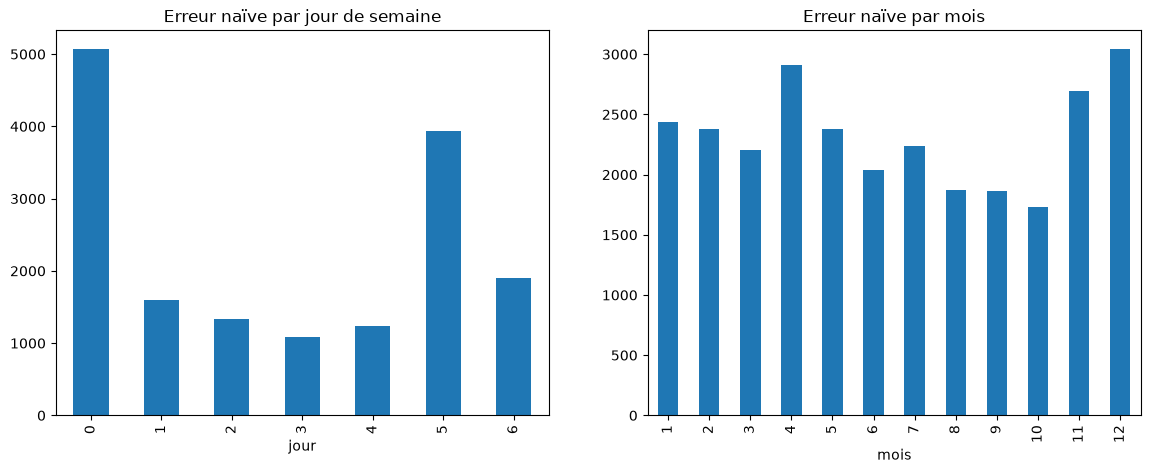

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
df_2024.groupby('jour')['erreur_jour'].mean().plot(kind='bar', ax=ax1, title='Erreur naïve par jour de semaine')
df_2024.groupby('mois')['erreur_jour'].mean().plot(kind='bar', ax=ax2, title='Erreur naïve par mois')

On voit clairement là où on se trompe le plus. Sur les jours de la semaine, on se trompe surtout pour le lundi et le samedi, 5000 MW et 4000 MW d'erreur respectivement, soit presque le double de notre erreur moyenne (2316 MW), on peut expliquer cela par le fait que ce soient les deux jours frontaliers entre jours de semaine et weekend, les deux tranches de la semaine qui varient le plus entre elles, et vu que la méthode naïve copie la veille, c'est exactement sur ces transitions qu'elle se plante.

Pour les mois, on se trompe surtout pour les mois d'avril, novembre et décembre, avec des erreurs autour des 3000 MW par jour pour ces 3 extremums, soit environ 30% de plus que la moyenne annuelle. En effet, ce sont des mois à météo instable où deux jours qui se suivent peuvent être très différents, et ce sont aussi des mois avec plusieurs jours fériés (Pâques, le 1er et le 11 novembre, Noël), des ruptures que la méthode naïve ne peut pas prévoir.

In [16]:
df_jour['weekend']=(df_jour['date'].dt.dayofweek >=5).astype(int)

In [17]:
df_jour=df_jour.dropna(subset=['conso_veille'])

In [18]:
len(df_jour)

730

In [19]:
train=df_jour[df_jour['date'].dt.year==2023]

In [20]:
test=df_jour[df_jour['date'].dt.year==2024]

In [21]:
len(train)

364

In [22]:
len(test)

366

In [23]:
from sklearn.linear_model import LinearRegression   

colonnes = ["conso_veille", "temp_france", "weekend"]  

X_train = train[colonnes]        
y_train = train["consommation"]  

modele = LinearRegression()      
modele.fit(X_train, y_train)     

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0.71, -369.83,-4427.36]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['conso_veille','temp_france','weekend']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.095e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [24]:
modele.coef_

array([ 7.07270810e-01, -3.69830183e+02, -4.42736187e+03])

In [25]:
predictions = modele.predict(test[colonnes])

In [26]:
mae_modele = (test["consommation"]    - predictions).abs().mean()

In [27]:
mae_modele

np.float64(1675.0085111199305)

On constate que notre modèle bat clairement la méthode naïve, avec une erreur moyenne de 1675 MW contre 2316 MW, soit une amélioration de 28%. Autrement dit, en donnant au modèle la conso de la veille, la température et le type de jour, on se trompe d'environ 3% de la consommation moyenne journalière, ce qui est déjà très correct pour un modèle linéaire à 3 paramètres.

Les coefficients du modèle confirment nos analyses précédentes, en effet, le coefficient du weekend vaut -4427 MW, ce qui correspond bien à l'écart semaine/weekend qu'on avait mesuré dans l'exploration (environ 5000 MW). Pour la température, le coefficient vaut seulement -370 MW/°C alors qu'on avait mesuré une thermosensibilité de -2066 MW/°C, on peut expliquer cela par la colinéarité entre nos variables : la conso de la veille contient déjà l'effet de la température de la veille, et comme la température change peu d'un jour à l'autre, le modèle n'attribue à la température que ce qu'elle apporte en plus, c'est à dire l'effet des variations de température entre deux jours. 

Pour être honnête, j'avais parié sur une erreur autour de 770 MW (l'erreur divisée par 3 vu qu'on a 3 paramètres), pari largement perdu, le nombre de paramètres ne divise pas l'erreur, chaque variable n'apporte que l'information nouvelle qu'elle contient. Le modèle reste aussi limité par ce qu'il ne connaît pas, notamment les jours fériés qu'il traite comme des jours normaux.